In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("hw3-task2.ipynb")

# Homework 3 - Task 2: Tree-Based Methods
## Predicting Water Potability Using Decision Trees and Random Forests

---


### Dataset

Access to safe drinking water is a fundamental public health concern. This dataset contains physicochemical measurements for 3,276 water samples, each labeled as potable or non-potable.

| Feature | Description |
|---|---|
| `ph` | pH value of water (0–14 scale) |
| `Hardness` | Capacity to precipitate soap (mg/L) |
| `Solids` | Total dissolved solids (ppm) |
| `Chloramines` | Amount of chloramines (ppm) |
| `Sulfate` | Amount of sulfates dissolved (mg/L) |
| `Conductivity` | Electrical conductivity (μS/cm) |
| `Organic_carbon` | Amount of organic carbon (ppm) |
| `Trihalomethanes` | Amount of trihalomethanes (μg/L) |
| `Turbidity` | Measure of light-emitting property (NTU) |

#### Response Variable

| Column | Description |
|---|---|
| `Potability` | Binary flag — `1` if water is safe to drink, `0` otherwise |


 **Note:** Several features contain missing values (`ph`, `Sulfate`, `Trihalomethanes`). You will handle these in the preprocessing step.

 This dataset comes from Kaggle and can be found [here](https://www.kaggle.com/datasets/uom190346a/water-quality-and-potability).

### Setup: Load Libraries

Run the cell below to import all required packages.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

### Step 1: Load the Data

Read `water_potability.csv` into a DataFrame. Preview the first few rows and confirm its shape.

In [3]:
df = pd.read_csv('water_potability.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (3276, 10)


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


### Step 2: Explore the Data

Before modeling, examine the distribution of your response variable and the number of NAs. Understanding both will guide preprocessing decisions.

In [4]:
# Binary variable: 60% of data is 0, 40% is 1
df['Potability'].value_counts(normalize=True)

Potability
0    0.60989
1    0.39011
Name: proportion, dtype: float64

In [5]:
# Number of NAs in each column 
df.isna().sum()

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

### Step 3: Preprocess the Data

Three features have missing values. A simple approach for tree-based methods is to **impute with the column median**. Impute the missing values using `df.fillna()`.Store your cleaned dataframe in a variable called `df_clean`. 

After imputation, split the data 70/30 into training and test sets, stratifying on `Potability` to preserve the class ratio in both splits.Store your results in `X_train`, `X_test`, `y_train`, and `y_test`.

In [6]:
# Impute missing values with column median into pH, Sulfate, and Turbidity columns 
df_clean = df.fillna(df.median(numeric_only=True))

# Predictors 
X = df_clean.drop(columns='Potability')
# Response 
y = df_clean['Potability']

# Split data training 70 and test 30,, stratifying on potability because it is categorical 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42)


In [7]:
grader.check("q1")

q1 results: All test cases passed!

### Step 4: Fit a Single Classification Tree

Start with an **unpruned** classification tree (no constraints on depth or leaf size). This gives a baseline and illustrates the overfitting problem that ensemble methods address.

Fit `DecisionTreeClassifier` with only `random_state=42` set (all other parameters at defaults). Report the tree depth in a variable named `tree_depth`. Calculate both the train accuracy and the test accuracy, storing the train accuracy in a variable called`dt_unpruned_acc_train` and the test accuracy in a variable called `dt_unpruned_acc_test`. 

In [8]:
 # Initializing model 
dt_unpruned = DecisionTreeClassifier(random_state = 42)  
# Fit model 
dt_unpruned.fit(X_train, y_train)
# Retrieve max depth of 'unpruned tree' 
tree_depth = dt_unpruned.get_depth()
# Calculate training accuracy of 'unpruned tree' 
dt_unpruned_acc_train = accuracy_score(y_train, dt_unpruned.predict(X_train))
# Calculate test accuracy of 'unpruned tree' 
dt_unpruned_acc_test  = accuracy_score(y_test, dt_unpruned.predict(X_test))

In [9]:
grader.check("q2")

q2 results: All test cases passed!

<!-- BEGIN QUESTION -->

>**Q1: How does the training accuracy and test accuracy differ? What does this mean about your model?**

In [10]:
dt_unpruned_acc_test

0.5808748728382502

Training accuracy is perfect (1) while test accuracy is ~ 0.58. This means the model is overfitting. 

<!-- END QUESTION -->

### Step 5: Tune Tree Depth with Cross-Validation

A fully grown tree memorizes the training data (better training accuracy, poor test accuracy). We need to find the right **depth** to prevent this. 

Using 5-fold cross-validation on the training set, compute mean CV accuracy for `max_depth` from 1 to 20. Identify the optimal depth using `np.argmax`, storing it in a variable called `optimal_depth`. Plot the CV Accuracy against the 20 different depths, adding a vertical line at the optimal depth. 

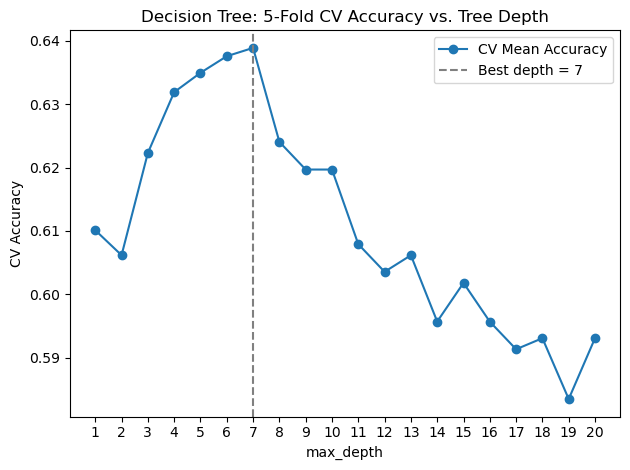

In [30]:
# Create a vector of depths from 1 to 20 
depths = range(1, 21)   
# Empty cross validation means vector                 
cv_means = []


for depth in depths: 
    dt = DecisionTreeClassifier(max_depth= depth, random_state= 42)
    scores = cross_val_score(dt, X_train, y_train, cv = 5, scoring = 'accuracy')
    cv_means.append(scores.mean())

cv_means = np.array(cv_means)                                  # Storing all means inside empty vector
optimal_depth = list(depths)[np.argmax(cv_means)]              # Pulling out depth corresponding to highest mean 

# Plot CV accuracy against 20 different depths 

plt.plot(list(depths), cv_means, label='CV Mean Accuracy', marker='o')
plt.axvline(optimal_depth, color='gray', linestyle='--', label=f'Best depth = {optimal_depth}')
plt.xlabel('max_depth')
plt.ylabel('CV Accuracy')
plt.xticks(list(depths))
plt.title('Decision Tree: 5-Fold CV Accuracy vs. Tree Depth')
plt.legend()
plt.tight_layout()
plt.show()


In [12]:
grader.check("q3")

q3 results: All test cases passed!

<!-- BEGIN QUESTION -->

> **Q2: What did cross fold validation find the optimal depth to be? Explain what these means in plain language.**

Cross fold validation found the best depth to be 7. This means that trees shallower than this underfit the data and deeper trees start memorizing noise in the training set and overfit.

<!-- END QUESTION -->

### Step 6: Fit the Tuned Decision Tree

Refit the decision tree using `optimal_depth` and evaluate on the held-out test set. Store the test accuracy in a variable called `acc_dt`. 

In [13]:
 # Initializing model 
dt_opt = DecisionTreeClassifier(random_state = 42, max_depth= optimal_depth) 
# Fit model 
dt_opt.fit(X_train, y_train)
# Calculate test accuracy of tuned tree 
acc_dt = accuracy_score(y_test, dt_opt.predict(X_test))

In [14]:
grader.check("q4")

q4 results: All test cases passed!

<!-- BEGIN QUESTION -->

>**Q3: Did the accuracy on your tuned decision tree imrpove compared to your untuned tree? If so, why do you think it improved?**

In [15]:
acc_dt

0.6459816887080366

Yes the test accuracy improved from ~0.58 to ~0.65. The untuned tree was overfitting, memorizing noise in the training data. Setting the depth to 7 allowed the model to focus on general patterns rather than fitting to noise, which helps it perform better on unseen data.

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

### Step 7: Visualize the Decision Tree

Plot the tuned tree using `plot_tree`. Save the tree as an image to evaluate the results and answer **Q5**. 

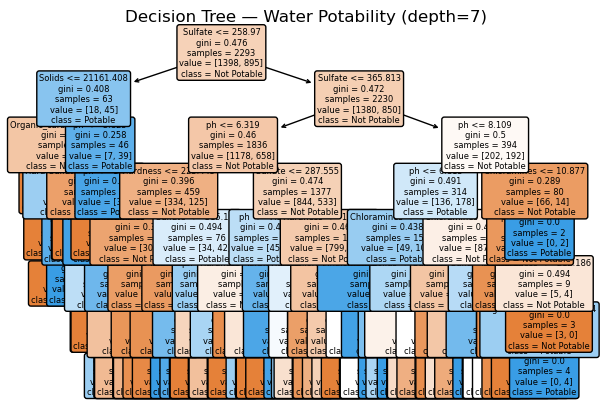

In [16]:
# Plot decision tree
plot_tree(
    dt_opt,
    feature_names=X_train.columns,             
    class_names=['Not Potable', 'Potable'],
    filled=True, rounded=True, fontsize=6,
)
plt.title('Decision Tree — Water Potability (depth=7)')
plt.show()

> **Q4: Examine the root node and first two levels of the tree. Which feature is used for the root split, and what threshold does it use? What does this tell you about that feature's relationship with potability? What is the Gini impurity at the root, and how does it change after the first split?**

Sulfate is being used for the root split. The threshold it uses is 258.97. This tells us that this is the most influential feature and that levels above this have a large effect on the potability of water. The gini impurity at the root is 0.476. After the first split, it decreases. 

<!-- END QUESTION -->

### Step 8: Random Forest

**Random forests** address the high variance of a single tree by fitting many trees on bootstrap samples of the training data and averaging their predictions. To further reduce correlation among the trees, at each split only a random subset of $m$ features is considered (by default sklearn uses $m = \lfloor\sqrt{p}\rfloor$ for classification).

Fit a `RandomForestClassifier`, called `rf` with `n_estimators=200`. Report the accuracy and store it in `acc_rf`. 

In [28]:
rf = RandomForestClassifier(
    n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
acc_rf  = accuracy_score(y_test,  rf.predict(X_test))

acc_rf

0.6642929806714141

Pretty sure this is right.

In [26]:
grader.check("q5")

q5 results:
    q5 - 1 result:
        ✅ Test case passed

    q5 - 2 result:
        ❌ Test case failed
        Trying:
            assert np.isclose(acc_rf, 0.6612, atol=0.001)
        Expecting nothing
        **********************************************************************
        Line 1, in q5 1
        Failed example:
            assert np.isclose(acc_rf, 0.6612, atol=0.001)
        Exception raised:
            Traceback (most recent call last):
              File "/opt/anaconda3/envs/eds232-env/lib/python3.10/doctest.py", line 1350, in __run
                exec(compile(example.source, filename, "single",
              File "<doctest q5 1[0]>", line 1, in <module>
                assert np.isclose(acc_rf, 0.6612, atol=0.001)
            AssertionError

<!-- BEGIN QUESTION -->

>**Q5: Compare the test results of Decision Tree and Random Forest? Which performed beter? Why do you think this is?**

The Random Forest (0.6642929806714141) performed marginally better than the Decision Tree (0.6459816887080366). This is because Random Forests reduce variance by averaging predictions over n amount of trees. In this case it was 200. 

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

### Step 9: Feature Importances

Both decision trees and random forests assign an **importance score** to each feature based on the total reduction in impurity (Gini) it produces across all splits. Random forest importances are averaged over all trees in the ensemble, making them more stable than a single tree's importances.

Create a bar plot showing the feature importances from the tuned decision tree and the random forest side by side. You can access the feature importants from the model wtih `model.feature_importances_`.

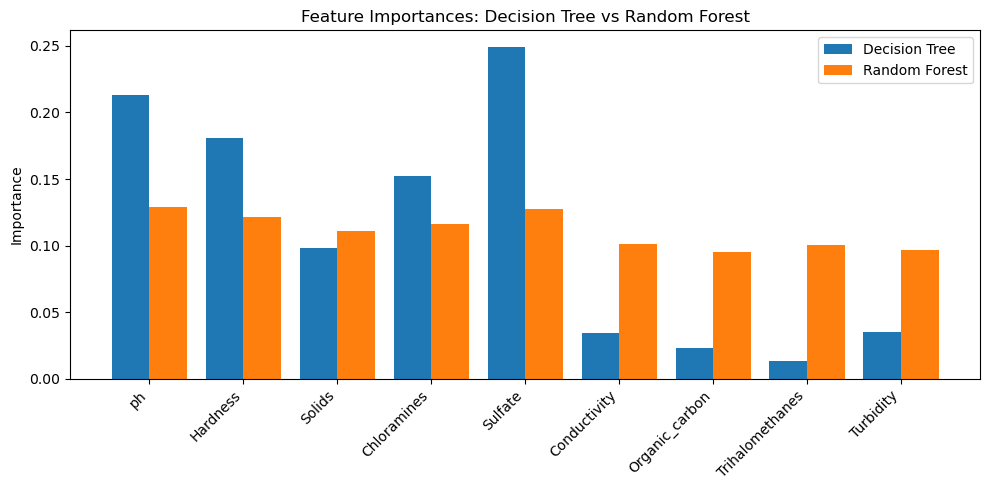

In [33]:
features = X_train.columns
x = np.arange(len(features))
width = 0.4

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, dt_opt.feature_importances_, width, label='Decision Tree')
ax.bar(x + width/2, rf.feature_importances_,     width, label='Random Forest')

ax.set_xticks(x)
ax.set_xticklabels(features, rotation=45, ha='right')
ax.set_ylabel('Importance')
ax.set_title('Feature Importances: Decision Tree vs Random Forest')
ax.legend()
plt.tight_layout()
plt.show()

> **Q6: Do the decision tree and random forest agree on which features are most important? If they differ, why might a single tree's importances be less reliable than the random forest's? Which feature appears most important for predicting potability, and does that make physical sense?**

Both models agree that pH, Hardness, Sulfates are the most important features. A single tree's importances might be less reliable because it picks one feature per split, so similar features might get overlooked. The forest averages across n number of trees with varied feature subset so similar features dont get overlooked. 

<!-- END QUESTION -->

### Step 10: Confusion Matrix

Create a confusion matrix for the random forest model using `ConfusionMatrixDisplay`. Label your response variable as `Not Potable`/ `Potable` in the confusion matrix (instead of `0`/`1`).

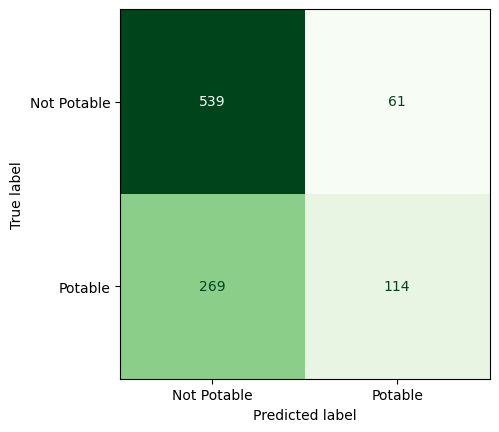

In [40]:
# Confusion Matrix 
ConfusionMatrixDisplay.from_estimator(
    rf, X_test, y_test,
    display_labels=['Not Potable', 'Potable'],
    cmap='Greens',
    colorbar=False,
)

<!-- BEGIN QUESTION -->

> **Q7:** Report the results of the confusion matrix. How many false positives, true positives, false negatives, and true negatives did your model predict? Interpret what each of those 4 results means in the context of the data.

Positive : Potable 
Negative: Not Potable 

True positive: 114: correctly identified safe water as potable
False positive: 61: incorrectly identified unsafe water as potable
False negative: 269: incorrectly identified safe water as not potable
True negative: 539: correctly identified unsafe water as not potable

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

### Step 11: Model Comparison

Create a table or bar chart comparing test accuracy across all three models.

In [42]:
# Table comparing test accuracy of all models 
pd.DataFrame({
    'Model': ['Unpruned Tree', 'Tuned Tree', 'Random Forest'],
    'Test Accuracy': [dt_unpruned_acc_test, acc_dt, acc_rf],
})

,Model,Test Accuracy
0,Unpruned Tree,0.580875
1,Tuned Tree,0.645982
2,Random Forest,0.664293


> **Q8:** Which model achieved the highest test accuracy? Comparing the unpruned and tuned decision tree, how much did pruning improve accuracy? What does this tell you about overfitting in the unpruned tree?


The Random Forest model achieved the highest test accuracy. Pruning improved accuracy by ~ 0.06. This tells us that the unpruned tree was overfitting the most. 

---

Run the cell below to receive credit for autograded questions. 

In [19]:
grader.check_all()

q1 results: All test cases passed!

q2 results: All test cases passed!

q3 results: All test cases passed!

q4 results: All test cases passed!

q5 results:
    q5 - 1 result:
        ✅ Test case passed

    q5 - 2 result:
        ❌ Test case failed
        Trying:
            assert np.isclose(acc_rf, 0.6612, atol=0.001)
        Expecting nothing
        **********************************************************************
        Line 1, in q5 1
        Failed example:
            assert np.isclose(acc_rf, 0.6612, atol=0.001)
        Exception raised:
            Traceback (most recent call last):
              File "/opt/anaconda3/envs/eds232-env/lib/python3.10/doctest.py", line 1350, in __run
                exec(compile(example.source, filename, "single",
              File "<doctest q5 1[0]>", line 1, in <module>
                assert np.isclose(acc_rf, 0.6612, atol=0.001)
            AssertionError